# Saliency Metrics Analysis

Analysis of saliency metrics across different models and threshold values.
Metrics are averaged across the test set for each random seed.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import re

# Set up paths and styles
plt.rcParams['grid.alpha'] = 0.3
current_dir = Path('.')
output_dir = Path('.')

# Define models and their display names
csv_files = {
    'ResNet, Bias=1.0': 'saliency_metrics_resnet_bias1.csv',
    'ResNet, Bias=10.0': 'saliency_metrics_resnet_bias10.csv',
    'SimpleCNN, Bias=1.0': 'saliency_metrics_simpleCNN_bias1.csv',
    'SimpleCNN, Bias=10.0': 'saliency_metrics_simpleCNN_bias10.csv',
}

# Load all CSV files
data = {}
for model_name, csv_file in csv_files.items():
    file_path = current_dir / csv_file
    if file_path.exists():
        data[model_name] = pd.read_csv(file_path)
        print(f"Loaded {model_name}: {data[model_name].shape}")
    else:
        print(f"Warning: {csv_file} not found")

print(f"\nTotal models loaded: {len(data)}")

Loaded ResNet, Bias=1.0: (47600, 49)
Loaded ResNet, Bias=10.0: (47600, 49)
Loaded SimpleCNN, Bias=1.0: (40800, 49)
Loaded SimpleCNN, Bias=10.0: (52700, 49)

Total models loaded: 4


In [4]:
def extract_seed_from_model_string(model_str):
    """Extract seed value from model string."""
    match = re.search(r'seed=(\d+)', model_str)
    if match:
        return int(match.group(1))
    return None

# Group by seed and average across images
data_grouped = {}
for model_name, df in data.items():
    # Extract seed from model column
    df_copy = df.copy()
    df_copy['seed'] = df_copy['model'].apply(extract_seed_from_model_string)
    
    # Group by seed and compute mean across images
    df_grouped = df_copy.groupby('seed').mean(numeric_only=True)
    
    data_grouped[model_name] = df_grouped
    print(f"{model_name}: Grouped shape = {df_grouped.shape} (seeds: {len(df_grouped)})")

print(f"\n✓ Grouping complete. Ready to extract threshold metrics.")

ResNet, Bias=1.0: Grouped shape = (28, 48) (seeds: 28)
ResNet, Bias=10.0: Grouped shape = (28, 48) (seeds: 28)
SimpleCNN, Bias=1.0: Grouped shape = (24, 48) (seeds: 24)
SimpleCNN, Bias=10.0: Grouped shape = (29, 48) (seeds: 29)

✓ Grouping complete. Ready to extract threshold metrics.


In [4]:
# Print seeds for inspection
print("Seeds extracted from each model:\n")
for model_name, df in data_grouped.items():
    seeds = sorted(df.index.tolist())
    print(f"{model_name}:")
    print(f"  Count: {len(seeds)}")
    print(f"  Seeds: {seeds}")
    print()

Seeds extracted from each model:

ResNet, Bias=1.0:
  Count: 28
  Seeds: [0, 1, 7, 11, 13, 21, 27, 31, 37, 42, 43, 49, 53, 59, 61, 67, 71, 73, 79, 89, 97, 98, 101, 103, 107, 113, 127, 143]

ResNet, Bias=10.0:
  Count: 28
  Seeds: [0, 1, 7, 11, 13, 21, 27, 31, 37, 42, 43, 49, 53, 59, 61, 67, 71, 73, 79, 89, 97, 98, 101, 103, 107, 113, 127, 143]

SimpleCNN, Bias=1.0:
  Count: 24
  Seeds: [0, 1, 11, 13, 21, 27, 31, 37, 42, 43, 49, 53, 59, 61, 67, 71, 73, 79, 97, 98, 101, 107, 113, 127]

SimpleCNN, Bias=10.0:
  Count: 29
  Seeds: [0, 1, 7, 11, 13, 21, 27, 31, 37, 42, 43, 49, 53, 59, 61, 67, 71, 73, 79, 89, 97, 98, 101, 103, 107, 109, 113, 127, 143]



In [5]:
# Remove specified seeds to make datasets consistent
seeds_to_remove = {
    'SimpleCNN, Bias=1.0': [109, 103, 89, 7, 143],
    'SimpleCNN, Bias=10.0': [109, 103, 89, 7, 143],
    'ResNet, Bias=1.0': [0, 127, 113],
    'ResNet, Bias=10.0': [0, 127, 113]
}

# Filter data_grouped
data_filtered = {}
for model_name, df in data_grouped.items():
    seeds_to_remove_for_model = seeds_to_remove.get(model_name, [])
    df_filtered = df.drop(seeds_to_remove_for_model, errors='ignore')
    data_filtered[model_name] = df_filtered

# Print final seeds after filtering
print("Final seeds after filtering:\n")
for model_name, df in data_filtered.items():
    seeds = sorted(df.index.tolist())
    print(f"{model_name}:")
    print(f"  Count: {len(seeds)}")
    print(f"  Seeds: {seeds}")
    print()

Final seeds after filtering:

ResNet, Bias=1.0:
  Count: 25
  Seeds: [1, 7, 11, 13, 21, 27, 31, 37, 42, 43, 49, 53, 59, 61, 67, 71, 73, 79, 89, 97, 98, 101, 103, 107, 143]

ResNet, Bias=10.0:
  Count: 25
  Seeds: [1, 7, 11, 13, 21, 27, 31, 37, 42, 43, 49, 53, 59, 61, 67, 71, 73, 79, 89, 97, 98, 101, 103, 107, 143]

SimpleCNN, Bias=1.0:
  Count: 24
  Seeds: [0, 1, 11, 13, 21, 27, 31, 37, 42, 43, 49, 53, 59, 61, 67, 71, 73, 79, 97, 98, 101, 107, 113, 127]

SimpleCNN, Bias=10.0:
  Count: 24
  Seeds: [0, 1, 11, 13, 21, 27, 31, 37, 42, 43, 49, 53, 59, 61, 67, 71, 73, 79, 97, 98, 101, 107, 113, 127]



In [6]:
def extract_threshold_metrics(df, metric_name):
    """
    Extract columns for a specific metric across all thresholds.
    Returns a dict with threshold -> values mapping.
    """
    pattern = f'{metric_name}_thresh_'
    threshold_cols = [col for col in df.columns if pattern in col]
    
    results = {}
    for col in sorted(threshold_cols):
        # Extract threshold value from column name
        match = re.search(r'thresh_([\d.]+)', col)
        if match:
            threshold = float(match.group(1))
            results[threshold] = df[col].values
    
    return results

# Define metrics to analyze
metrics = [
    'cc_num_clusters',
    'cc_avg_cluster_size',
    'cc_cluster_size_ratio',
    'salient_pixels_percent',
    'cc_avg_inter_cluster_distance',
    'cc_max_inter_cluster_distance'
]

# Process all metrics for all models using filtered data
results_data = {}
for model_name, df in data_filtered.items():
    results_data[model_name] = {}
    for metric in metrics:
        threshold_values = extract_threshold_metrics(df, metric)
        if threshold_values:
            results_data[model_name][metric] = threshold_values
            print(f"{model_name} - {metric}: {len(threshold_values)} thresholds found")

print("\nMetric extraction complete!")

ResNet, Bias=1.0 - cc_num_clusters: 5 thresholds found
ResNet, Bias=1.0 - cc_avg_cluster_size: 5 thresholds found
ResNet, Bias=1.0 - cc_cluster_size_ratio: 5 thresholds found
ResNet, Bias=1.0 - salient_pixels_percent: 5 thresholds found
ResNet, Bias=1.0 - cc_avg_inter_cluster_distance: 5 thresholds found
ResNet, Bias=1.0 - cc_max_inter_cluster_distance: 5 thresholds found
ResNet, Bias=10.0 - cc_num_clusters: 5 thresholds found
ResNet, Bias=10.0 - cc_avg_cluster_size: 5 thresholds found
ResNet, Bias=10.0 - cc_cluster_size_ratio: 5 thresholds found
ResNet, Bias=10.0 - salient_pixels_percent: 5 thresholds found
ResNet, Bias=10.0 - cc_avg_inter_cluster_distance: 5 thresholds found
ResNet, Bias=10.0 - cc_max_inter_cluster_distance: 5 thresholds found
SimpleCNN, Bias=1.0 - cc_num_clusters: 5 thresholds found
SimpleCNN, Bias=1.0 - cc_avg_cluster_size: 5 thresholds found
SimpleCNN, Bias=1.0 - cc_cluster_size_ratio: 5 thresholds found
SimpleCNN, Bias=1.0 - salient_pixels_percent: 5 thresholds f

In [7]:
def prepare_statistics(results_data, metric):
    """
    Prepare statistics (mean and std) for a metric across all models.
    Returns a dict with model -> {thresholds, means, stds}.
    """
    stats = {}
    for model_name in results_data:
        if metric in results_data[model_name]:
            threshold_values = results_data[model_name][metric]
            
            # Sort by threshold
            sorted_thresholds = sorted(threshold_values.keys())
            means = []
            stds = []
            
            for threshold in sorted_thresholds:
                values = threshold_values[threshold]
                means.append(np.mean(values))
                stds.append(np.std(values))
            
            stats[model_name] = {
                'thresholds': np.array(sorted_thresholds),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return stats

# Define metric display names for titles
metric_titles = {
    'cc_num_clusters': 'Connected Component Count vs Saliency Threshold',
    'cc_avg_cluster_size': 'Average Cluster Size vs Saliency Threshold',
    'cc_cluster_size_ratio': 'Cluster Size Ratio vs Saliency Threshold',
    'salient_pixels_percent': 'Salient Pixels Percentage vs Saliency Threshold',
    'cc_avg_inter_cluster_distance': 'Average Inter-Cluster Distance vs Saliency Threshold',
    'cc_max_inter_cluster_distance': 'Maximum Inter-Cluster Distance vs Saliency Threshold'
}

# Define color map for models
colors = {
    'ResNet, Bias=1.0': '#1f77b4',
    'ResNet, Bias=10.0': '#ff7f0e',
    'SimpleCNN, Bias=1.0': '#2ca02c',
    'SimpleCNN, Bias=10.0': '#d62728',
}

print("Statistics preparation functions ready!")

Statistics preparation functions ready!


Saved: cc_num_clusters_vs_threshold.png


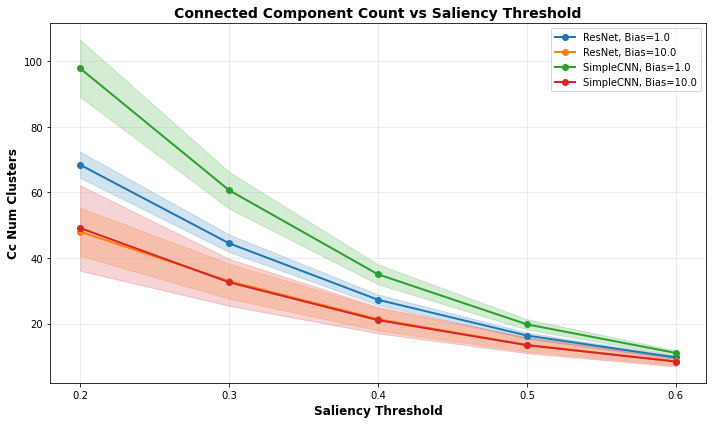

Saved: cc_avg_cluster_size_vs_threshold.png


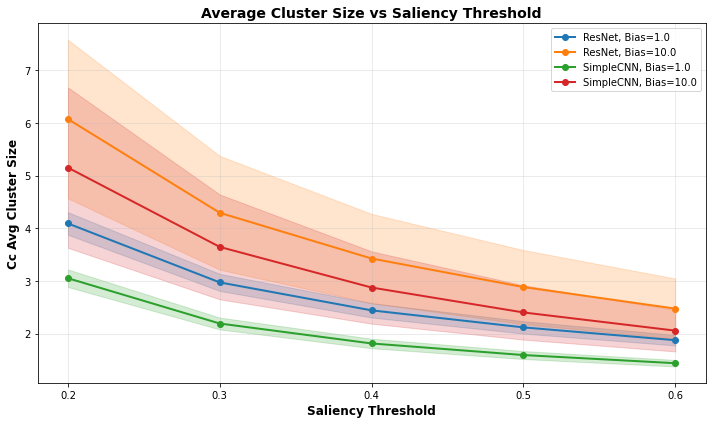

Saved: cc_cluster_size_ratio_vs_threshold.png


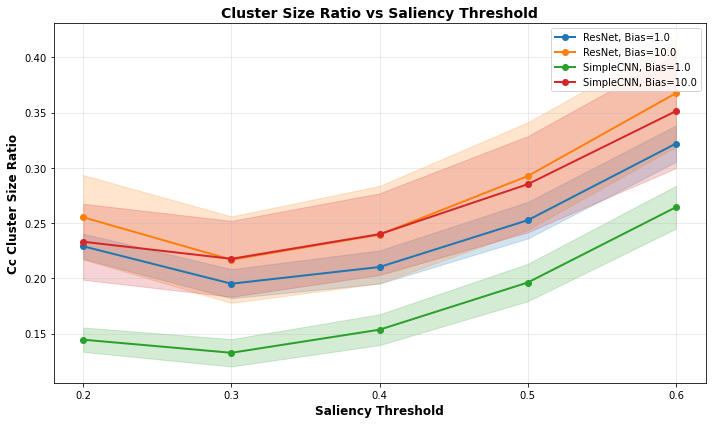

Saved: salient_pixels_percent_vs_threshold.png


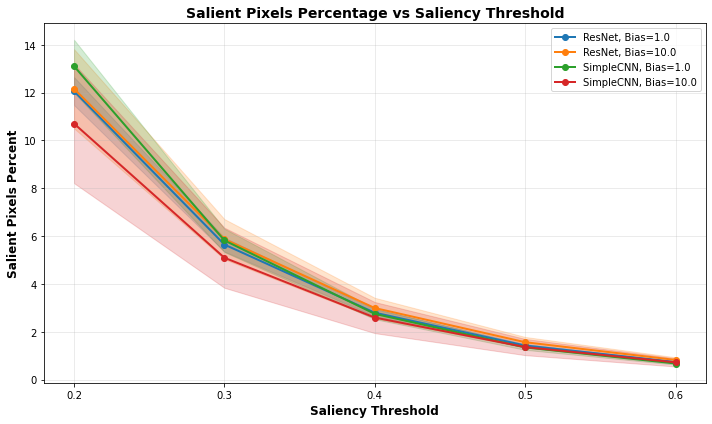

Saved: cc_avg_inter_cluster_distance_vs_threshold.png


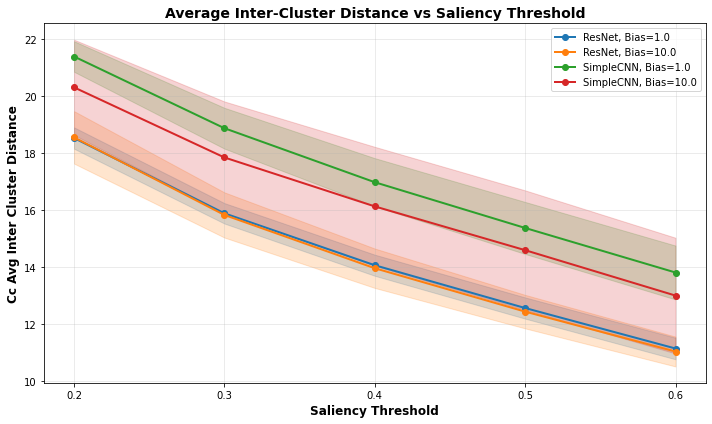

Saved: cc_max_inter_cluster_distance_vs_threshold.png


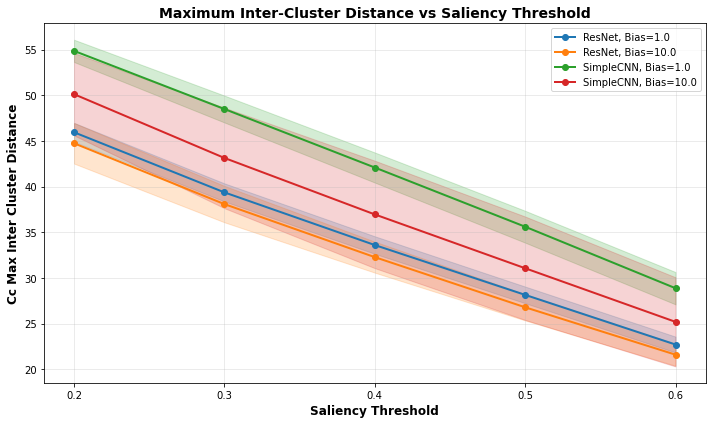


All figures generated successfully!


In [8]:
# Create figures for each metric
for metric in metrics:
    stats = prepare_statistics(results_data, metric)
    
    if not stats:
        print(f"Skipping {metric}: no data found")
        continue
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot each model
    for model_name in sorted(stats.keys()):
        stat = stats[model_name]
        color = colors[model_name]
        
        # Plot line
        ax.plot(stat['thresholds'], stat['mean'], 
                marker='o', linewidth=2, label=model_name, color=color)
        
        # Plot confidence region
        ax.fill_between(stat['thresholds'], 
                        stat['mean'] - stat['std'],
                        stat['mean'] + stat['std'],
                        alpha=0.2, color=color)
    
    # Formatting
    ax.set_xlabel('Saliency Threshold', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_title(metric_titles[metric], fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Ensure thresholds are in ascending order on x-axis
    ax.set_xticks(sorted(stats[list(stats.keys())[0]]['thresholds']))
    
    plt.tight_layout()
    
    # Save figure
    fig_name = f"{metric}_vs_threshold.png"
    fig_path = output_dir / fig_name
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {fig_name}")
    
    plt.show()

print("\nAll figures generated successfully!")

In [9]:
# Generate paper-ready tables for each metric
for metric in metrics:
    stats = prepare_statistics(results_data, metric)
    
    if not stats:
        print(f"Skipping table for {metric}: no data found")
        continue
    
    # Get common thresholds
    common_thresholds = stats[list(stats.keys())[0]]['thresholds']
    
    # Create table data
    table_data = []
    for model_name in sorted(stats.keys()):
        stat = stats[model_name]
        for i, threshold in enumerate(common_thresholds):
            mean_val = stat['mean'][i]
            std_val = stat['std'][i]
            table_data.append({
                'Model': model_name,
                'Threshold': f"{threshold:.1f}",
                'Mean': f"{mean_val:.4f}",
                'Std': f"{std_val:.4f}",
                'Mean ± Std': f"{mean_val:.4f} ± {std_val:.4f}"
            })
    
    df_table = pd.DataFrame(table_data)
    
    # Display table
    print(f"\n{'='*100}")
    print(f"Metric: {metric.upper()}")
    print(f"{'='*100}")
    print(df_table.to_string(index=False))
    
    # Save table as CSV
    table_name = f"{metric}_vs_threshold_table.csv"
    df_table.to_csv(output_dir / table_name, index=False)
    print(f"\nTable saved: {table_name}")


Metric: CC_NUM_CLUSTERS
               Model Threshold    Mean     Std        Mean ± Std
    ResNet, Bias=1.0       0.2 68.4204  3.9884  68.4204 ± 3.9884
    ResNet, Bias=1.0       0.3 44.4718  2.6766  44.4718 ± 2.6766
    ResNet, Bias=1.0       0.4 27.2480  1.6123  27.2480 ± 1.6123
    ResNet, Bias=1.0       0.5 16.3326  0.9197  16.3326 ± 0.9197
    ResNet, Bias=1.0       0.6  9.6383  0.4728   9.6383 ± 0.4728
   ResNet, Bias=10.0       0.2 48.0101  7.3215  48.0101 ± 7.3215
   ResNet, Bias=10.0       0.3 32.9342  5.3409  32.9342 ± 5.3409
   ResNet, Bias=10.0       0.4 21.3144  3.4287  21.3144 ± 3.4287
   ResNet, Bias=10.0       0.5 13.4792  2.0559  13.4792 ± 2.0559
   ResNet, Bias=10.0       0.6  8.4092  1.1281   8.4092 ± 1.1281
 SimpleCNN, Bias=1.0       0.2 97.8365  8.7329  97.8365 ± 8.7329
 SimpleCNN, Bias=1.0       0.3 60.6725  5.5973  60.6725 ± 5.5973
 SimpleCNN, Bias=1.0       0.4 35.0047  3.0281  35.0047 ± 3.0281
 SimpleCNN, Bias=1.0       0.5 19.7472  1.5697  19.7472 ± 1.5697


In [ ]:
# Summary statistics
print("\n" + "="*100)
print("SUMMARY STATISTICS")
print("="*100)

for metric in metrics:
    stats = prepare_statistics(results_data, metric)
    print(f"\n{metric.upper()}:")
    print("-" * 50)
    
    for model_name in sorted(stats.keys()):
        stat = stats[model_name]
        print(f"\n  {model_name}:")
        print(f"    Thresholds: {stat['thresholds']}")
        print(f"    Mean range: [{stat['mean'].min():.4f}, {stat['mean'].max():.4f}]")
        print(f"    Std range: [{stat['std'].min():.4f}, {stat['std'].max():.4f}]")

Saved: cc_num_clusters_threshold_03_barplot.png


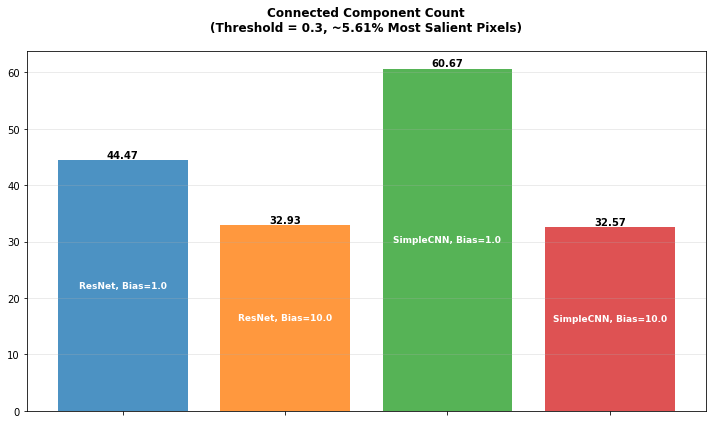

Saved: cc_avg_cluster_size_threshold_03_barplot.png


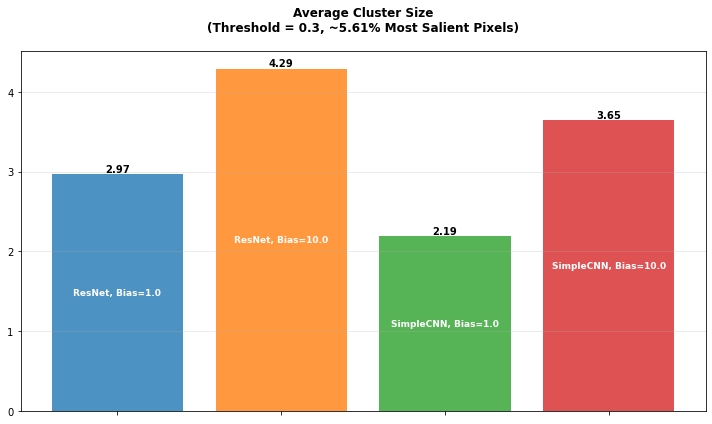

Saved: cc_cluster_size_ratio_threshold_03_barplot.png


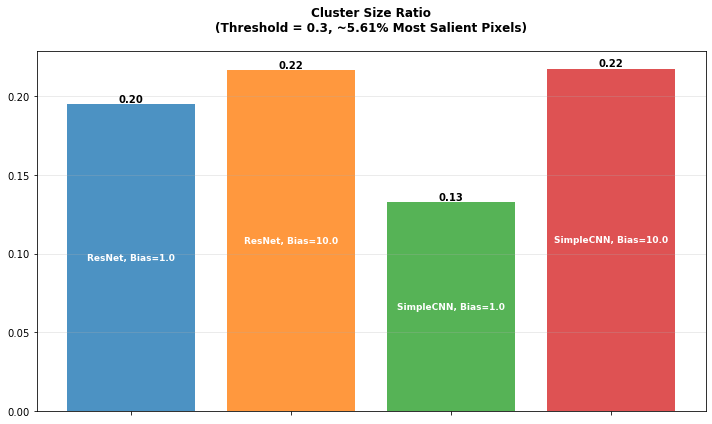

Saved: salient_pixels_percent_threshold_03_barplot.png


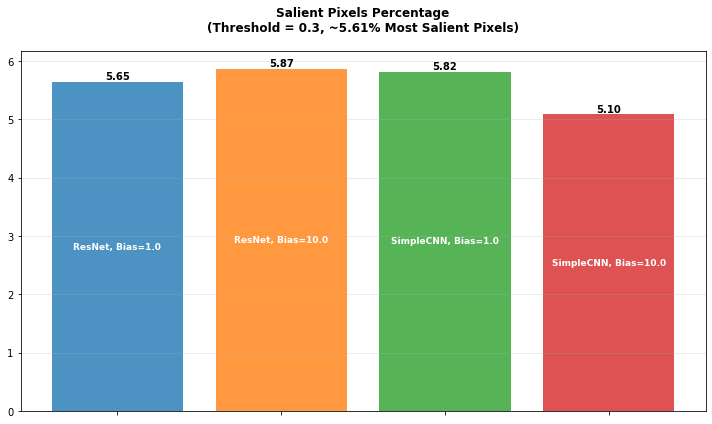

Saved: cc_avg_inter_cluster_distance_threshold_03_barplot.png


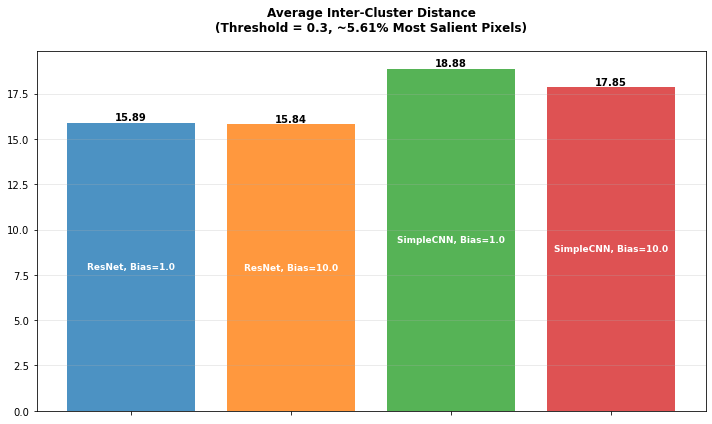

Saved: cc_max_inter_cluster_distance_threshold_03_barplot.png


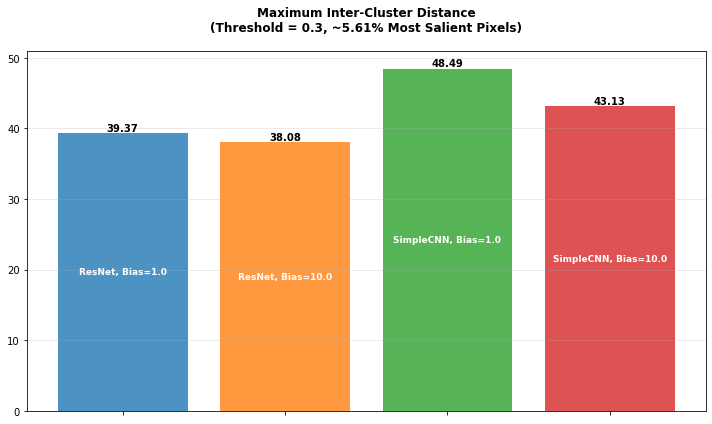


All bar plots generated successfully!


In [ ]:
# Create bar plots for threshold = 0.3
threshold_target = 0.3

# Get salient pixels percentages at threshold 0.3
salient_pixels_at_03 = {}
for model_name in sorted(results_data.keys()):
    if 'salient_pixels_percent' in results_data[model_name]:
        threshold_values = results_data[model_name]['salient_pixels_percent']
        if threshold_target in threshold_values:
            mean_val = np.mean(threshold_values[threshold_target])
            salient_pixels_at_03[model_name] = mean_val

# Calculate overall average salient pixels percentage at 0.3
avg_salient_pixels_03 = np.mean(list(salient_pixels_at_03.values()))

# Create bar plots for each metric at threshold 0.3
for metric in metrics:
    stats = prepare_statistics(results_data, metric)
    
    if not stats:
        print(f"Skipping {metric}: no data found")
        continue
    
    # Extract data for threshold 0.3
    models_list = sorted(stats.keys())
    means_at_03 = []
    
    for model_name in models_list:
        stat = stats[model_name]
        # Find index where threshold = 0.3
        idx = np.where(stat['thresholds'] == threshold_target)[0]
        if len(idx) > 0:
            means_at_03.append(stat['mean'][idx[0]])
        else:
            means_at_03.append(np.nan)
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bar_colors = [colors[model_name] for model_name in models_list]
    bars = ax.bar(range(len(models_list)), means_at_03, color=bar_colors, alpha=0.8)
    
    # Add model names on bars and values above
    for i, (bar, model_name, value) in enumerate(zip(bars, models_list, means_at_03)):
        # Add model name on the bar (centered)
        bar_height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, bar_height/2, model_name,
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        
        # Add value above the bar
        ax.text(bar.get_x() + bar.get_width()/2, bar_height, f'{value:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Set title with threshold and average salient pixels
    metric_title = metric_titles[metric].split(' vs ')[0]  # Remove "vs Saliency Threshold"
    title = f"{metric_title}\n(Threshold = {threshold_target:.1f}, ~{avg_salient_pixels_03:.2f}% Most Salient Pixels)"
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
    
    # Formatting - remove axis labels
    ax.set_xticks(range(len(models_list)))
    ax.set_xticklabels([])
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Save figure
    fig_name = f"{metric}_threshold_03_barplot.png"
    fig_path = output_dir / fig_name
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {fig_name}")
    
    plt.show()

print("\nAll bar plots generated successfully!")


FACE PARTS COVERAGE AND ATTRIBUTION ANALYSIS (Threshold = 0.3)

Face Parts Coverage:
  ResNet, Bias=1.0: Eyes=14.09%, Mouth=11.16%, Nose=15.78% (Total: 41.03%)
  ResNet, Bias=10.0: Eyes=14.55%, Mouth=7.33%, Nose=17.03% (Total: 38.91%)
  SimpleCNN, Bias=1.0: Eyes=10.32%, Mouth=7.59%, Nose=13.04% (Total: 30.95%)
  SimpleCNN, Bias=10.0: Eyes=11.85%, Mouth=7.99%, Nose=11.66% (Total: 31.50%)
Saved: face_parts_coverage_threshold_03_barplot.png



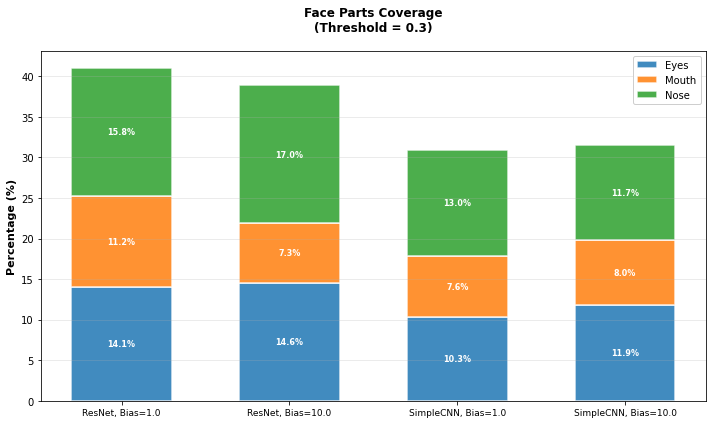


Face Parts Attribution:
  ResNet, Bias=1.0: Eyes=12.06%, Mouth=10.34%, Nose=12.65% (Total: 35.06%)
  ResNet, Bias=10.0: Eyes=12.28%, Mouth=8.05%, Nose=13.28% (Total: 33.61%)
  SimpleCNN, Bias=1.0: Eyes=9.35%, Mouth=8.09%, Nose=10.68% (Total: 28.11%)
  SimpleCNN, Bias=10.0: Eyes=11.29%, Mouth=9.25%, Nose=11.06% (Total: 31.61%)
Saved: face_parts_attribution_threshold_03_barplot.png



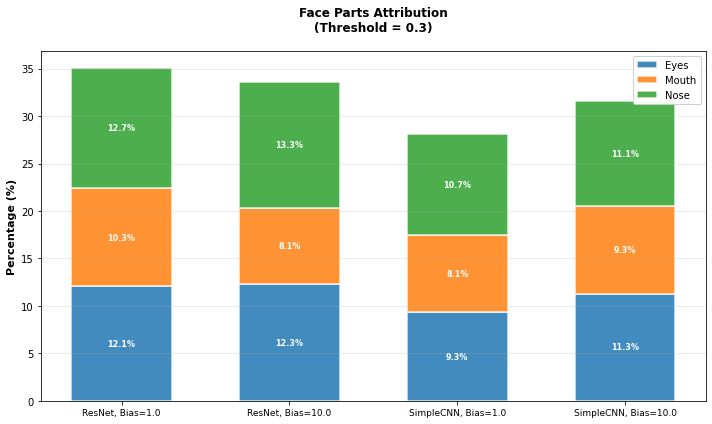

All face parts analysis plots generated successfully!


In [26]:
# Create stacked bar plots for face parts coverage and attribution (threshold = 0.3)
print("\n" + "="*100)
print("FACE PARTS COVERAGE AND ATTRIBUTION ANALYSIS (Threshold = 0.3)")
print("="*100)

# Define face parts metrics with individual components
face_parts_metrics = [
    {
        'name': 'coverage',
        'columns': ['coverage_eyes', 'coverage_mouth', 'coverage_nose'],
        'title': 'Face Parts Coverage',
        'part_names': ['Eyes', 'Mouth', 'Nose'],
        'part_colors': ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    },
    {
        'name': 'attribution',
        'columns': ['attribution_eyes', 'attribution_mouth', 'attribution_nose'],
        'title': 'Face Parts Attribution',
        'part_names': ['Eyes', 'Mouth', 'Nose'],
        'part_colors': ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    }
]

threshold_030 = 0.30

for face_metric in face_parts_metrics:
    metric_name = face_metric['name']
    columns_to_sum = face_metric['columns']
    part_names = face_metric['part_names']
    part_colors = face_metric['part_colors']
    title = face_metric['title']
    
    print(f"\n{title}:")
    
    # Calculate individual contributions for each model
    contributions_per_model = {}
    
    for model_name in sorted(data_filtered.keys()):
        df = data_filtered[model_name]
        
        # Check which columns exist
        available_cols = [col for col in columns_to_sum if col in df.columns]
        
        if available_cols:
            # Calculate individual averages (multiply by 100 to get percentage)
            contributions = {}
            for col, part_name in zip(columns_to_sum, part_names):
                if col in df.columns:
                    contributions[part_name] = (df[col].mean()) * 100
                else:
                    contributions[part_name] = 0
            
            contributions_per_model[model_name] = contributions
            total = sum(contributions.values())
            print(f"  {model_name}: Eyes={contributions['Eyes']:.2f}%, Mouth={contributions['Mouth']:.2f}%, Nose={contributions['Nose']:.2f}% (Total: {total:.2f}%)")
        else:
            print(f"  {model_name}: columns not found")
    
    if not contributions_per_model:
        print(f"Skipping {metric_name}: no columns found")
        continue
    
    # Create stacked bar plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    models_list = sorted(contributions_per_model.keys())
    
    # Prepare data for stacked bars
    bar_width = 0.6
    x_pos = np.arange(len(models_list))
    
    # Initialize bottom for stacking
    bottom = np.zeros(len(models_list))
    bars_list = []
    
    # Create stacked bars for each body part
    for i, (part_name, part_color) in enumerate(zip(part_names, part_colors)):
        values = [contributions_per_model[model][part_name] for model in models_list]
        bars = ax.bar(x_pos, values, bar_width, label=part_name, bottom=bottom, 
                     color=part_color, alpha=0.85, edgecolor='white', linewidth=1.5)
        bars_list.append(bars)
        
        # Add value labels on each segment
        for j, (bar, value) in enumerate(zip(bars, values)):
            if value > 0:  # Only add label if value is significant
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2, bottom[j] + height/2, 
                       f'{value:.1f}%', ha='center', va='center', fontsize=8, 
                       fontweight='bold', color='white')
        
        bottom += np.array(values)
    
    # Set title
    plot_title = f"{title}\n(Threshold = {threshold_030:.1f})"
    ax.set_title(plot_title, fontsize=12, fontweight='bold', pad=20)
    
    # Add legend
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
    
    # Formatting
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models_list, fontsize=9)
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set y-axis to show percentages
    ax.set_ylim(0, max(bottom) * 1.05)
    
    plt.tight_layout()
    
    # Save figure
    fig_name = f"face_parts_{metric_name}_threshold_03_barplot.png"
    fig_path = output_dir / fig_name
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {fig_name}\n")
    
    plt.show()

print("All face parts analysis plots generated successfully!")

In [27]:
# Statistical testing: p-values for coverage columns (Bias 1.0 vs Bias 10.0)
from scipy import stats

print("\n" + "="*100)
print("STATISTICAL TESTING: COVERAGE COLUMNS (Bias 1.0 vs Bias 10.0)")
print("="*100)

coverage_columns = ['coverage_eyes', 'coverage_mouth', 'coverage_nose']

# Get data for each architecture
resnet_bias1_data = data_filtered['ResNet, Bias=1.0']
resnet_bias10_data = data_filtered['ResNet, Bias=10.0']
simplecnn_bias1_data = data_filtered['SimpleCNN, Bias=1.0']
simplecnn_bias10_data = data_filtered['SimpleCNN, Bias=10.0']

# Store results
results = []

print("\nResNet: Bias 1.0 vs Bias 10.0")
print("-" * 50)
for col in coverage_columns:
    if col in resnet_bias1_data.columns and col in resnet_bias10_data.columns:
        data1 = resnet_bias1_data[col].values
        data2 = resnet_bias10_data[col].values
        
        # Perform independent t-test
        t_stat, p_value = stats.ttest_ind(data1, data2)
        
        mean1 = data1.mean()
        mean2 = data2.mean()
        
        print(f"{col}:")
        print(f"  Bias 1.0: mean={mean1:.4f}, std={data1.std():.4f}")
        print(f"  Bias 10.0: mean={mean2:.4f}, std={data2.std():.4f}")
        print(f"  t-statistic: {t_stat:.4f}, p-value: {p_value:.6f}")
        if p_value < 0.05:
            print(f"  *** SIGNIFICANT (p < 0.05)")
        print()
        
        results.append({
            'Architecture': 'ResNet',
            'Column': col,
            'Mean (Bias 1.0)': mean1,
            'Mean (Bias 10.0)': mean2,
            't-statistic': t_stat,
            'p-value': p_value,
            'Significant (p<0.05)': 'Yes' if p_value < 0.05 else 'No'
        })

print("SimpleCNN: Bias 1.0 vs Bias 10.0")
print("-" * 50)
for col in coverage_columns:
    if col in simplecnn_bias1_data.columns and col in simplecnn_bias10_data.columns:
        data1 = simplecnn_bias1_data[col].values
        data2 = simplecnn_bias10_data[col].values
        
        # Perform independent t-test
        t_stat, p_value = stats.ttest_ind(data1, data2)
        
        mean1 = data1.mean()
        mean2 = data2.mean()
        
        print(f"{col}:")
        print(f"  Bias 1.0: mean={mean1:.4f}, std={data1.std():.4f}")
        print(f"  Bias 10.0: mean={mean2:.4f}, std={data2.std():.4f}")
        print(f"  t-statistic: {t_stat:.4f}, p-value: {p_value:.6f}")
        if p_value < 0.05:
            print(f"  *** SIGNIFICANT (p < 0.05)")
        print()
        
        results.append({
            'Architecture': 'SimpleCNN',
            'Column': col,
            'Mean (Bias 1.0)': mean1,
            'Mean (Bias 10.0)': mean2,
            't-statistic': t_stat,
            'p-value': p_value,
            'Significant (p<0.05)': 'Yes' if p_value < 0.05 else 'No'
        })

# Create summary table
print("\nSUMMARY TABLE")
print("="*100)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Save results
results_csv = output_dir / 'coverage_pvalues_bias_comparison.csv'
df_results.to_csv(results_csv, index=False)
print(f"\nResults saved to: coverage_pvalues_bias_comparison.csv")



STATISTICAL TESTING: COVERAGE COLUMNS (Bias 1.0 vs Bias 10.0)

ResNet: Bias 1.0 vs Bias 10.0
--------------------------------------------------
coverage_eyes:
  Bias 1.0: mean=0.1409, std=0.0123
  Bias 10.0: mean=0.1455, std=0.0226
  t-statistic: -0.8927, p-value: 0.376466

coverage_mouth:
  Bias 1.0: mean=0.1116, std=0.0101
  Bias 10.0: mean=0.0733, std=0.0191
  t-statistic: 8.6802, p-value: 0.000000
  *** SIGNIFICANT (p < 0.05)

coverage_nose:
  Bias 1.0: mean=0.1578, std=0.0093
  Bias 10.0: mean=0.1703, std=0.0226
  t-statistic: -2.4950, p-value: 0.016087
  *** SIGNIFICANT (p < 0.05)

SimpleCNN: Bias 1.0 vs Bias 10.0
--------------------------------------------------
coverage_eyes:
  Bias 1.0: mean=0.1032, std=0.0325
  Bias 10.0: mean=0.1185, std=0.0533
  t-statistic: -1.1810, p-value: 0.243670

coverage_mouth:
  Bias 1.0: mean=0.0759, std=0.0156
  Bias 10.0: mean=0.0799, std=0.0243
  t-statistic: -0.6537, p-value: 0.516546

coverage_nose:
  Bias 1.0: mean=0.1304, std=0.0181
  Bias